In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import time
from copy import deepcopy as copy
from scipy.optimize import minimize
import torch
# np.random.seed(1)
# torch.random.manual_seed(1)

import sys
sys.path.append('../')  #for savo import
sys.path.append('../../machineIO/')  #for machineIO import
from savo import savo
from savo.model import GaussianProcess as GP
from savo.optim import adam
from machineIO.objFunc import SingleTaskObjectiveFunction
from machineIO.VM import VirtualMachineIO
from machineIO import Evaluator 

Failed to import 'epics'
Failed to import 'phantasy'


In [ ]:
ndim = 20
budget = 100
model_train_budget = 180
ninit = 5  # number of initial ES steps to collect data for surrogate model training
noise = 0.0 # 1e-3
max_dx = 1e-2
lr = 0.2
lrES = 0.01


In [3]:
control_CSETs = [f'X{i}:I_CSET' for i in range(ndim)]
control_RDs   = [f'X{i}:I_RD'   for i in range(ndim)]
control_min   =  np.zeros(ndim) #-np.ones(ndim)
control_max   =  np.ones(ndim)
control_maxstep = max_dx*np.ones(ndim)
control_tols  = 1e-3*(control_max-control_min)
monitor_RDs   = [f'Y{i}:I_RD' for i in range(1)]

objective_PVs = monitor_RDs
composite_objective_name = 'composite_objective'

# obj_func

In [ ]:
def rastrigin(x, noise=0.0):
    x = torch.as_tensor(x)
    d = x.shape[-1]
    y = torch.sum(x**2 - torch.cos(2*np.pi*x), dim=-1) /(d*control_max[0]**2)
    return 1 - y + torch.randn_like(y) * noise

def rosenbrock(x, noise=0.0):
    x = torch.as_tensor(x)
    a = 1
    b = 100
    d = x.shape[-1]
    x1 = x[..., :-1]  # x_i (all but last element)
    x2 = x[..., 1:]   # x_{i+1} (all but first element)
    y = torch.sum((a - x1)**2 + b * (x2 - x1**2)**2, dim=-1)/(b*d*control_max[0]**4)
    return 1 - y + torch.randn_like(y) * noise

def sphere(x, noise=0.0):
    x = torch.as_tensor(x)
    d = x.shape[-1]
    y = torch.mean(3*(x-0.8)**2, dim=-1)
    return 1 - y + torch.randn_like(y) * noise

def apply_bilog(f):
    return lambda x: torch.sign(f(x)) * torch.log(1 + torch.abs(f(x)))

In [5]:
objective_func = sphere
fname = f'[benchmark]{objective_func.__name__}{ndim}D'

In [6]:
def get_grad(f, x):
    x_ = x.clone().requires_grad_(True)
    y = f(x_)
    y = y.sum()
    y.backward()
    dydx = x_.grad
    return dydx

In [7]:
vmio = VirtualMachineIO(
    control_CSETs = control_CSETs,
    control_RDs = control_RDs,
    monitor_RDs = monitor_RDs,
    control_min = control_min,
    control_max = control_max,
    fetch_data_time_span = 1.0,
    fun = objective_func,
)

In [8]:
def composite_objective_func(y):
    return y

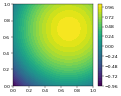

In [9]:
xgrid0 = np.linspace(control_min[0],control_max[0],128)
xgrid1 = np.linspace(control_min[1],control_max[1],128)
xgrid0,xgrid1 = np.meshgrid(xgrid0,xgrid1)
xgrid = np.vstack((xgrid0.flatten(), xgrid1.flatten())).T
ygrid = objective_func(xgrid,noise=0)
def plot_contour(fig,ax):
    cs = ax.tricontourf(xgrid[:,0],xgrid[:,1],ygrid,levels=32)
    fig.colorbar(cs,ax=ax)
fig,ax = plt.subplots(figsize=(4,3.3),dpi=32)
plot_contour(fig,ax)

In [10]:
obj_func = SingleTaskObjectiveFunction(
    objective_PVs = monitor_RDs,
    composite_objective_name = composite_objective_name,
    custom_function = composite_objective_func,
    objective_goal = None, 
    objective_weight = None,
    objective_tolerance = None,
)

In [11]:
evaluator = Evaluator(
    machineIO = vmio,
    control_CSETs = control_CSETs,
    control_RDs = control_RDs,
    control_tols = control_tols,
    monitor_RDs = monitor_RDs,
    df_manipulators = [obj_func.calculate_objectives_from_df],
)

In [12]:
def magnitude_similarity(A, B):
    """
    Compute magnitude similarity between batches of vectors.
    
    Parameters:
    A, B: numpy arrays of shape (nsamples, ndim)
    
    Returns:
    sim: numpy array of shape (nsamples,) with similarity scores
    """
    if A.shape != B.shape:
        raise ValueError("A and B must have the same shape")
    
    norms_A = np.linalg.norm(A, axis=1)
    norms_B = np.linalg.norm(B, axis=1)
    
    mins = np.minimum(norms_A, norms_B)
    maxs = np.maximum(norms_A, norms_B)
    
    # Handle case where both norms are zero (division by zero)
    sim = np.where(maxs == 0, 1.0, mins / (maxs+1e-4))
    return sim

In [13]:
def summerize(sv):
    x = torch.tensor(np.array(sv.history['x'   ]),dtype=torch.float64)
    y = torch.tensor(np.array(sv.history['y'   ]),dtype=torch.float64)
    cpu_time = sv.history['cpu_time']   

    summery = {'x':x.numpy(), 'y':y.numpy(), 
               'ybest':np.array([y[:i].max() for i in range(1, len(y)+1)]), 
               'cpu_time':cpu_time}
    
    history = sv.history
    if len(history['dydx'])>0:
        ninit = len(history['x'])-len(history['dydx'])
        dxdy = np.array(history['dydx'])
        cov_trace = np.array(history['cov_trace'])
        dxdy_true = get_grad(objective_func, x[ninit:]).numpy()
        cos_sim = np.sum(dxdy*dxdy_true,axis=1)/(np.linalg.norm(dxdy,axis=1)+1e-4)/(np.linalg.norm(dxdy_true,axis=1)+1e-4)
        mag_sim = magnitude_similarity(dxdy,dxdy_true)

        summery['dydx'] = np.concatenate([np.empty((ninit, dxdy.shape[1])), dxdy])
        summery['dydx_true'] = np.concatenate([np.empty((ninit, dxdy.shape[1])), dxdy_true])
        summery['cos_sim'] = np.array([None]*ninit + list(cos_sim))
        summery['mag_sim'] = np.array([None]*ninit + list(mag_sim))
        summery['cov_trace'] = np.array([None]*ninit + list(cov_trace))
        if len(history['probability'])>0:
            summery['probability'] = np.array([None]*ninit + list(np.array(history['probability'])))

    return summery

In [14]:
def optimize_with_nelder_mead(savo,  max_evals=budget): #delta=0.1*max_dx*ndim**0.5,
    x0 = savo.x
    n = len(x0)
    delta=max_dx*ndim**0.5

    # Create initial simplex: first vertex is x0,
    # others are x0 + delta along each dimension
    initial_simplex = [x0]
    for i in range(n):
        vertex = np.array(x0, copy=True)
        vertex[i] += delta
        initial_simplex.append(vertex)
    initial_simplex = np.array(initial_simplex)

    def loss_fn(x):
        return savo.evaluate(x)

    result = minimize(
        loss_fn,
        x0,
        method='Nelder-Mead',
        options={
            'initial_simplex': initial_simplex,
            'maxfev': max_evals,
        }
    )
    return result

In [15]:
def run_one_instance(seed):
    np.random.seed(seed)
    torch.random.manual_seed(seed+173)

    results = {}

    x0 = np.random.uniform(control_min, control_max)

    _,_ = evaluator._set_and_read(x0)
    evaluator.clear_history()
    NM = savo(control_CSETs, control_RDs, control_min, control_max, control_maxstep, objective_PVs, composite_objective_name, evaluator)
    result = optimize_with_nelder_mead(NM,max_evals=budget)
    summery = summerize(NM)
    results['NM'] = summery
    print('NM done')

    _,_ = evaluator._set_and_read(x0)
    evaluator.clear_history()
    sv = savo(control_CSETs, control_RDs, control_min, control_max, control_maxstep, objective_PVs, composite_objective_name, evaluator, lrES=lrES)
    for i in range(budget):
        sv.step(lr=0)
    summery = summerize(sv)
    results['ES'] = summery
    print('ES done')

    _,_ = evaluator._set_and_read(x0)
    evaluator.clear_history()
    sv = savo(control_CSETs, control_RDs, control_min, control_max, control_maxstep, objective_PVs, composite_objective_name, evaluator, 
            model_train_budget = model_train_budget, lrES=lrES)
    for i in range(ninit):
        sv.step(lr=0)
    for i in range(budget-ninit):
        sv.step(lr=lr)
    summery = summerize(sv)
    results['ES+SG'] = summery
    print('ES+SG done')

    _,_ = evaluator._set_and_read(x0)
    evaluator.clear_history()
    sv = savo(control_CSETs, control_RDs, control_min, control_max, control_maxstep, objective_PVs, composite_objective_name, evaluator, 
            model_train_budget = model_train_budget, lrES=lrES, optimizer=adam())
    for i in range(ninit):
        sv.step(lr=0)
    for i in range(budget-ninit):
        sv.step(lr=lr)
    summery = summerize(sv)
    results['ES+SGadam'] = summery
    print('ES+SGadam done')

    _,_ = evaluator._set_and_read(x0)
    evaluator.clear_history()
    sv = savo(control_CSETs, control_RDs, control_min, control_max, control_maxstep, objective_PVs, composite_objective_name, evaluator, 
            model_train_budget = model_train_budget, lrES=lrES, optimizer = adam())
    for i in range(ninit):
        sv.step(lr=0)
    for i in range(budget-ninit):
        sv.step(lr=lr,penalize_uncertain_gradient=True)
    summery = summerize(sv)
    results['ES+uSGadam'] = summery
    print('ES+uSGadam done')

    _,_ = evaluator._set_and_read(x0)
    evaluator.clear_history()
    sv = savo(control_CSETs, control_RDs, control_min, control_max, control_maxstep, objective_PVs, composite_objective_name, evaluator, 
            model_train_budget = model_train_budget, lrES=lrES)
    for i in range(ninit):
        sv.step(lr=0)
    for i in range(budget-ninit):
        sv.step(lr=lr,lrES_scaler=0.0)
    summery = summerize(sv)
    results['SG'] = summery
    print('SG done')

    _,_ = evaluator._set_and_read(x0)
    evaluator.clear_history()
    sv = savo(control_CSETs, control_RDs, control_min, control_max, control_maxstep, objective_PVs, composite_objective_name, evaluator, 
            model_train_budget = model_train_budget, lrES=lrES, optimizer=adam())
    for i in range(ninit):
        sv.step(lr=0)
    for i in range(budget-ninit):
        sv.step(lr=lr,lrES_scaler=0.0)
    summery = summerize(sv)
    results['SGadam'] = summery
    print('SGadam done')

    _,_ = evaluator._set_and_read(x0)
    evaluator.clear_history()
    sv = savo(control_CSETs, control_RDs, control_min, control_max, control_maxstep, objective_PVs, composite_objective_name, evaluator, 
            model_train_budget = model_train_budget, lrES=lrES, optimizer=adam())
    for i in range(ninit):
        sv.step(lr=0)
    for i in range(budget-ninit):
        sv.step(lr=lr,lrES_scaler=0.0,penalize_uncertain_gradient=True)
    summery = summerize(sv)
    results['uSGadam'] = summery
    print('uSGadam done')

    _,_ = evaluator._set_and_read(x0)
    evaluator.clear_history()
    sv = savo(control_CSETs, control_RDs, control_min, control_max, control_maxstep, objective_PVs, composite_objective_name, evaluator, 
            model_train_budget = model_train_budget, lrES=lrES)
    for i in range(ninit):
        sv.step(lr=0)
    for i in range(budget-ninit):
        sv.step(TurBO=True)
    summery = summerize(sv)
    results['TurBO'] = summery
    print('TurBO done')

    return results

In [ ]:
results = []
seeds = list(range(2))
for seed in seeds:
    results.append(run_one_instance(seed))
df = pd.DataFrame(results, index=seeds)

NM done
ES done
ES+SG done
ES+SGadam done
ES+uSGadam done


c:\Users\HWANG\AppData\Local\Programs\Python\Python311\Lib\site-packages\gpytorch\distributions\multivariate_normal.py:319: NumericalWarning: Negative variance values detected. This is likely due to numerical instabilities. Rounding negative variances up to 1e-10.
  warnings.warn(


SG done


c:\Users\HWANG\AppData\Local\Programs\Python\Python311\Lib\site-packages\gpytorch\distributions\multivariate_normal.py:319: NumericalWarning: Negative variance values detected. This is likely due to numerical instabilities. Rounding negative variances up to 1e-10.
  warnings.warn(
c:\Users\HWANG\AppData\Local\Programs\Python\Python311\Lib\site-packages\gpytorch\distributions\multivariate_normal.py:319: NumericalWarning: Negative variance values detected. This is likely due to numerical instabilities. Rounding negative variances up to 1e-10.
  warnings.warn(


SGadam done
uSGadam done
TurBO done


In [24]:
df.to_pickle(f'{fname}.pkl')

In [25]:
df = pd.read_pickle(f'{fname}.pkl')

In [26]:
df

,NM,ES,ES+SG,ES+SGadam,ES+uSGadam,SG,SGadam,uSGadam,TurBO
0,"{'x': [[0.5488135039273248, 0.7151893663724195...","{'x': [[0.5488135039273248, 0.7151893663724195...","{'x': [[0.5864321571441982, 0.7151893663724195...","{'x': [[0.5488135039273248, 0.7151893663724195...","{'x': [[0.5488135039273248, 0.7151893663724195...","{'x': [[0.5488135039273248, 0.7151893663724195...","{'x': [[0.5488135039273248, 0.7151893663724195...","{'x': [[0.5488135039273248, 0.7151893663724195...","{'x': [[0.5488135039273248, 0.7151893663724195..."
1,"{'x': [[0.5488135039273248, 0.7151893663724195...","{'x': [[0.5488135039273248, 0.7151893663724195...","{'x': [[0.5864321571441982, 0.7151893663724195...","{'x': [[0.5488135039273248, 0.7151893663724195...","{'x': [[0.5488135039273248, 0.7151893663724195...","{'x': [[0.5488135039273248, 0.7151893663724195...","{'x': [[0.5488135039273248, 0.7151893663724195...","{'x': [[0.5488135039273248, 0.7151893663724195...","{'x': [[0.5488135039273248, 0.7151893663724195..."
